In [13]:
import pandas as pd

In [14]:
train_data = pd.read_csv(
    "/Users/mohitag/Documents/Projects/Customer_Churn_Project/Data/Raw/train.csv"
)

In [15]:
test_data = pd.read_csv(
    "/Users/mohitag/Documents/Projects/Customer_Churn_Project/Data/Raw/test.csv"
)
test_data.shape

(104480, 20)

In [16]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 243787 entries, 0 to 243786
Data columns (total 21 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   AccountAge                243787 non-null  int64  
 1   MonthlyCharges            243787 non-null  float64
 2   TotalCharges              243787 non-null  float64
 3   SubscriptionType          243787 non-null  str    
 4   PaymentMethod             243787 non-null  str    
 5   PaperlessBilling          243787 non-null  str    
 6   ContentType               243787 non-null  str    
 7   MultiDeviceAccess         243787 non-null  str    
 8   DeviceRegistered          243787 non-null  str    
 9   ViewingHoursPerWeek       243787 non-null  float64
 10  AverageViewingDuration    243787 non-null  float64
 11  ContentDownloadsPerMonth  243787 non-null  int64  
 12  GenrePreference           243787 non-null  str    
 13  UserRating                243787 non-null  float64
 14 

In [17]:
train_data.shape

(243787, 21)

In [18]:
train_data.describe()

,AccountAge,MonthlyCharges,TotalCharges,ViewingHoursPerWeek,AverageViewingDuration,ContentDownloadsPerMonth,UserRating,SupportTicketsPerMonth,WatchlistSize,Churn
count,243787.000000,243787.000000,243787.000000,243787.000000,243787.000000,243787.000000,243787.000000,243787.000000,243787.000000,243787.000000
mean,60.083758,12.490695,750.741017,20.502179,92.264061,24.503513,3.002713,4.504186,12.018508,0.181232
std,34.285143,4.327615,523.073273,11.243753,50.505243,14.421174,1.155259,2.872548,7.193034,0.385211
min,1.000000,4.990062,4.991154,1.000065,5.000547,0.000000,1.000007,0.000000,0.000000,0.000000
25%,30.000000,8.738543,329.147027,10.763953,48.382395,12.000000,2.000853,2.000000,6.000000,0.000000
50%,60.000000,12.495555,649.878487,20.523116,92.249992,24.000000,3.002261,4.000000,12.000000,0.000000
75%,90.000000,16.238160,1089.317362,30.219396,135.908048,37.000000,4.002157,7.000000,18.000000,0.000000
max,119.000000,19.989957,2378.723844,39.999723,179.999275,49.000000,4.999989,9.000000,24.000000,1.000000


<Axes: >

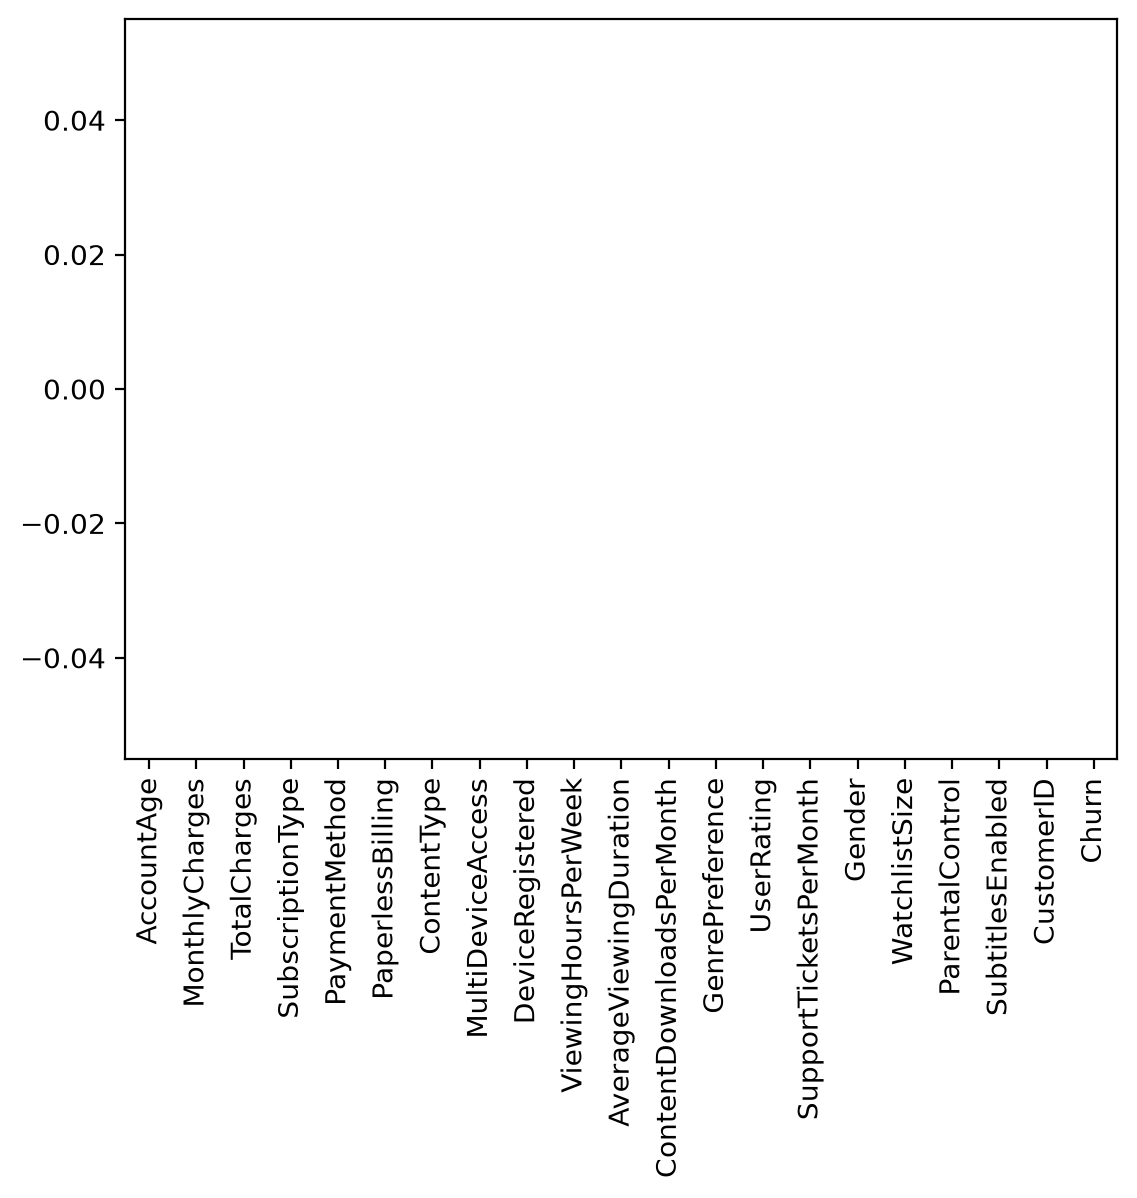

In [19]:
train_data.isna().sum().plot(kind="bar")

In [20]:
train_data.head()

,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,ViewingHoursPerWeek,...,ContentDownloadsPerMonth,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn
0,20,11.055215,221.104302,Premium,Mailed check,No,Both,No,Mobile,36.758104,...,10,Sci-Fi,2.176498,4,Male,3,No,No,CB6SXPNVZA,0
1,57,5.175208,294.986882,Basic,Credit card,Yes,Movies,No,Tablet,32.450568,...,18,Action,3.478632,8,Male,23,No,Yes,S7R2G87O09,0
2,73,12.106657,883.785952,Basic,Mailed check,Yes,Movies,No,Computer,7.395160,...,23,Fantasy,4.238824,6,Male,1,Yes,Yes,EASDC20BDT,0
3,32,7.263743,232.439774,Basic,Electronic check,No,TV Shows,No,Tablet,27.960389,...,30,Drama,4.276013,2,Male,24,Yes,Yes,NPF69NT69N,0
4,57,16.953078,966.325422,Premium,Electronic check,Yes,TV Shows,No,TV,20.083397,...,20,Comedy,3.616170,4,Female,0,No,No,4LGYPK7VOL,0


In [21]:
train_data["CustomerID"].duplicated().sum()

np.int64(0)

In [22]:
train_data["SubscriptionType"].unique()

<StringArray>
['Premium', 'Basic', 'Standard']
Length: 3, dtype: str

In [23]:
train_data["ContentType"].unique()

<StringArray>
['Both', 'Movies', 'TV Shows']
Length: 3, dtype: str

In [24]:
import duckdb as db

In [28]:
train_data.dtypes

AccountAge                    int64
MonthlyCharges              float64
TotalCharges                float64
SubscriptionType                str
PaymentMethod                   str
PaperlessBilling                str
ContentType                     str
MultiDeviceAccess               str
DeviceRegistered                str
ViewingHoursPerWeek         float64
AverageViewingDuration      float64
ContentDownloadsPerMonth      int64
GenrePreference                 str
UserRating                  float64
SupportTicketsPerMonth        int64
Gender                          str
WatchlistSize                 int64
ParentalControl                 str
SubtitlesEnabled                str
CustomerID                      str
Churn                         int64
dtype: object

In [35]:
DTYPE_MAP = {
    "int64": "INTEGER",
    "float64": "DOUBLE",
    "object": "VARCHAR",
    "bool": "BOOLEAN",
}

In [42]:
PRIMARY_KEY = "CustomerID"


In [ ]:
sql_colums = []
for col, dtype in train_data.dtypes.items():
    col_sql_type = DTYPE_MAP.get(str(dtype), "VARCHAR")
    print(col, col_sql_type)
    if col == PRIMARY_KEY:
        sql_colums.append(f"{col} VARCHAR PRIMARY_KEY")
    else:
        sql_colums.append(f"{col} {col_sql_type}")

AccountAge INTEGER
MonthlyCharges DOUBLE
TotalCharges DOUBLE
SubscriptionType VARCHAR
PaymentMethod VARCHAR
PaperlessBilling VARCHAR
ContentType VARCHAR
MultiDeviceAccess VARCHAR
DeviceRegistered VARCHAR
ViewingHoursPerWeek DOUBLE
AverageViewingDuration DOUBLE
ContentDownloadsPerMonth INTEGER
GenrePreference VARCHAR
UserRating DOUBLE
SupportTicketsPerMonth INTEGER
Gender VARCHAR
WatchlistSize INTEGER
ParentalControl VARCHAR
SubtitlesEnabled VARCHAR
CustomerID VARCHAR
Churn INTEGER


In [58]:
str = "(\n" + ",\n".join(sql_colums) + "\n)"

In [59]:
print(str)

(
AccountAge INTEGER,
MonthlyCharges DOUBLE,
TotalCharges DOUBLE,
SubscriptionType VARCHAR,
PaymentMethod VARCHAR,
PaperlessBilling VARCHAR,
ContentType VARCHAR,
MultiDeviceAccess VARCHAR,
DeviceRegistered VARCHAR,
ViewingHoursPerWeek DOUBLE,
AverageViewingDuration DOUBLE,
ContentDownloadsPerMonth INTEGER,
GenrePreference VARCHAR,
UserRating DOUBLE,
SupportTicketsPerMonth INTEGER,
Gender VARCHAR,
WatchlistSize INTEGER,
ParentalControl VARCHAR,
SubtitlesEnabled VARCHAR,
CustomerID VARCHAR PRIMARY_KEY,
Churn INTEGER
)
